# Drive Cycle Comparison: WLTP vs Nurburgring

This notebook compares standard road driving (WLTP) with high-performance track driving (Nurburgring) using PyBaMM simulation with the BYD Blade Prismatic 135Ah LFP cell.

## Overview
- **Cell**: BYD Blade Prismatic 135Ah LFP
- **Pack Configuration**: 120S3P (~100 kWh, 400V)
- **Drive Cycles**: 
  - **WLTP**: Worldwide Harmonized Light-Duty Test Procedure (23.3 km)
  - **Nurburgring**: Nordschleife track (20.8 km)
  
## Objectives
1. Simulate both drive cycles with identical battery configuration
2. Compare energy consumption, efficiency, and thermal behavior
3. Analyze range implications for different driving scenarios

## 1. Load Cell Parameters

Load the BYD Blade Prismatic 135Ah cell design from manifest.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from model_library.spmet_drive import run_drive_cycle, print_drive_cycle_report

In [2]:
# Load BYD Blade cell manifest
manifest_path = Path("../cells/BYD_Blade_Prismatic_135Ah_manifest.json")
material_path = Path("../materials")

with open(manifest_path, 'r') as f:
    cell_design_manifest = json.load(f)
    
    # Load material data for separator and electrolyte
    for component in ["separator", "electrolyte"]:
        print(f"Loading material data for {component}") 
        material_name = cell_design_manifest["cell_design"][component]["material"]["type"]
        material_file_path = material_path / f"{material_name}.json"
        with open(material_file_path, "r") as mf:
            material_data = json.load(mf)
            cell_design_manifest["cell_design"][component]["material"] = material_data

    # Load material data for electrodes
    for component in ["negative_electrode", "positive_electrode"]:
        print(f"Loading material data for {component}") 
        material_name = cell_design_manifest["cell_design"][component]["coating"]["formulation"]["primary_active_material"]["name"]
        material_file_path = material_path / f"{material_name}.json"
        with open(material_file_path, "r") as mf:
            material_data = json.load(mf)
            cell_design_manifest["cell_design"][component]["material"] = material_data

# Extract key parameters
nominal_capacity = cell_design_manifest['kpis']['nominal_capacity']['value']
nominal_energy = cell_design_manifest["kpis"]["nominal_energy"]["value"] 
cell_design = cell_design_manifest["cell_design"]
upper_voltage_cutoff = cell_design["upper_voltage_cutoff"]["value"]
lower_voltage_cutoff = cell_design["lower_voltage_cutoff"]["value"]

# Add required fields
cell_nominal_voltage = cell_design_manifest['kpis']['nominal_voltage']['value']
cell_design["nominal_capacity"] = {"value": nominal_capacity, "unit": "Ah"}
cell_design["nominal_energy"] = {"value": nominal_energy, "unit": "Wh"}
cell_design["cell_volume"] = {
    "value": cell_design_manifest['kpis']['cell_volume']['value'],
    "unit": "cm3"
}
cell_design["nominal_voltage"] = {
    "value": cell_nominal_voltage,
    "unit": "V"
}

print(f"\nCell loaded: {nominal_capacity} Ah, {nominal_energy} Wh")
print(f"Voltage range: {lower_voltage_cutoff} - {upper_voltage_cutoff} V")

Loading material data for separator
Loading material data for electrolyte
Loading material data for negative_electrode
Loading material data for positive_electrode

Cell loaded: 135.707 Ah, 434.262 Wh
Voltage range: 2.5 - 3.65 V


In [3]:
# Battery pack configuration (120S3P for ~100 kWh)
pack_config = {
    "pack_max_energy_kWh": 120,      # ~400V nominal (120 cells × 3.3V)
    "pack_nominal_voltage_V": 400,      # 3P for high current capability
    "rated_peak_power_kW": 50,
}
pack_config["pack_cells_in_series"] = int(pack_config["pack_nominal_voltage_V"] / cell_design["nominal_voltage"]["value"])
pack_config["pack_cells_in_parallel"] = int((pack_config["pack_max_energy_kWh"] * 1000) / (nominal_capacity * pack_config["pack_cells_in_series"]))
total_cells = pack_config["pack_cells_in_series"] * pack_config["pack_cells_in_parallel"]

print(f"Battery Pack Configuration:")
print(f"  Configuration: {pack_config['pack_cells_in_series']}S{pack_config['pack_cells_in_parallel']}P")
print(f"  Total cells: {total_cells}")
print(f"  Nominal voltage: {pack_config['pack_nominal_voltage_V']:.0f} V")
print(f"  Max power: {pack_config['rated_peak_power_kW']:.1f} kW")
print(f"  Energy: {pack_config['pack_max_energy_kWh']:.1f} kWh")

Battery Pack Configuration:
  Configuration: 125S7P
  Total cells: 875
  Nominal voltage: 400 V
  Max power: 50.0 kW
  Energy: 120.0 kWh


In [4]:
# Load WLTP cycle (standard road driving)
wltp_path = Path("../drive_cycles/Auto WLTP Power.csv")
wltp_data = pd.read_csv(wltp_path)

# Load Nurburgring track cycle (high-performance racing)
nurburgring_path = Path("../drive_cycles/Track Nurburgring Power.csv")
nurburgring_data = pd.read_csv(nurburgring_path)

print("WLTP Cycle:")
print(f"  Data points: {len(wltp_data)}")
print(f"  Duration: {wltp_data['time (s)'].max()} s ({wltp_data['time (s)'].max()/60:.1f} min)")
print(f"  Power range: {wltp_data['power (W)'].min():.1f} to {wltp_data['power (W)'].max():.1f} W")

print("\nNurburgring Cycle:")
print(f"  Data points: {len(nurburgring_data)}")
print(f"  Duration: {nurburgring_data['time (s)'].max()} s ({nurburgring_data['time (s)'].max()/60:.1f} min)")
print(f"  Power range: {nurburgring_data['power (W)'].min():.1f} to {nurburgring_data['power (W)'].max():.1f} W")

WLTP Cycle:
  Data points: 3601
  Duration: 3600 s (60.0 min)
  Power range: -80.9 to 0.0 W

Nurburgring Cycle:
  Data points: 420
  Duration: 419 s (7.0 min)
  Power range: -161.9 to 89.7 W


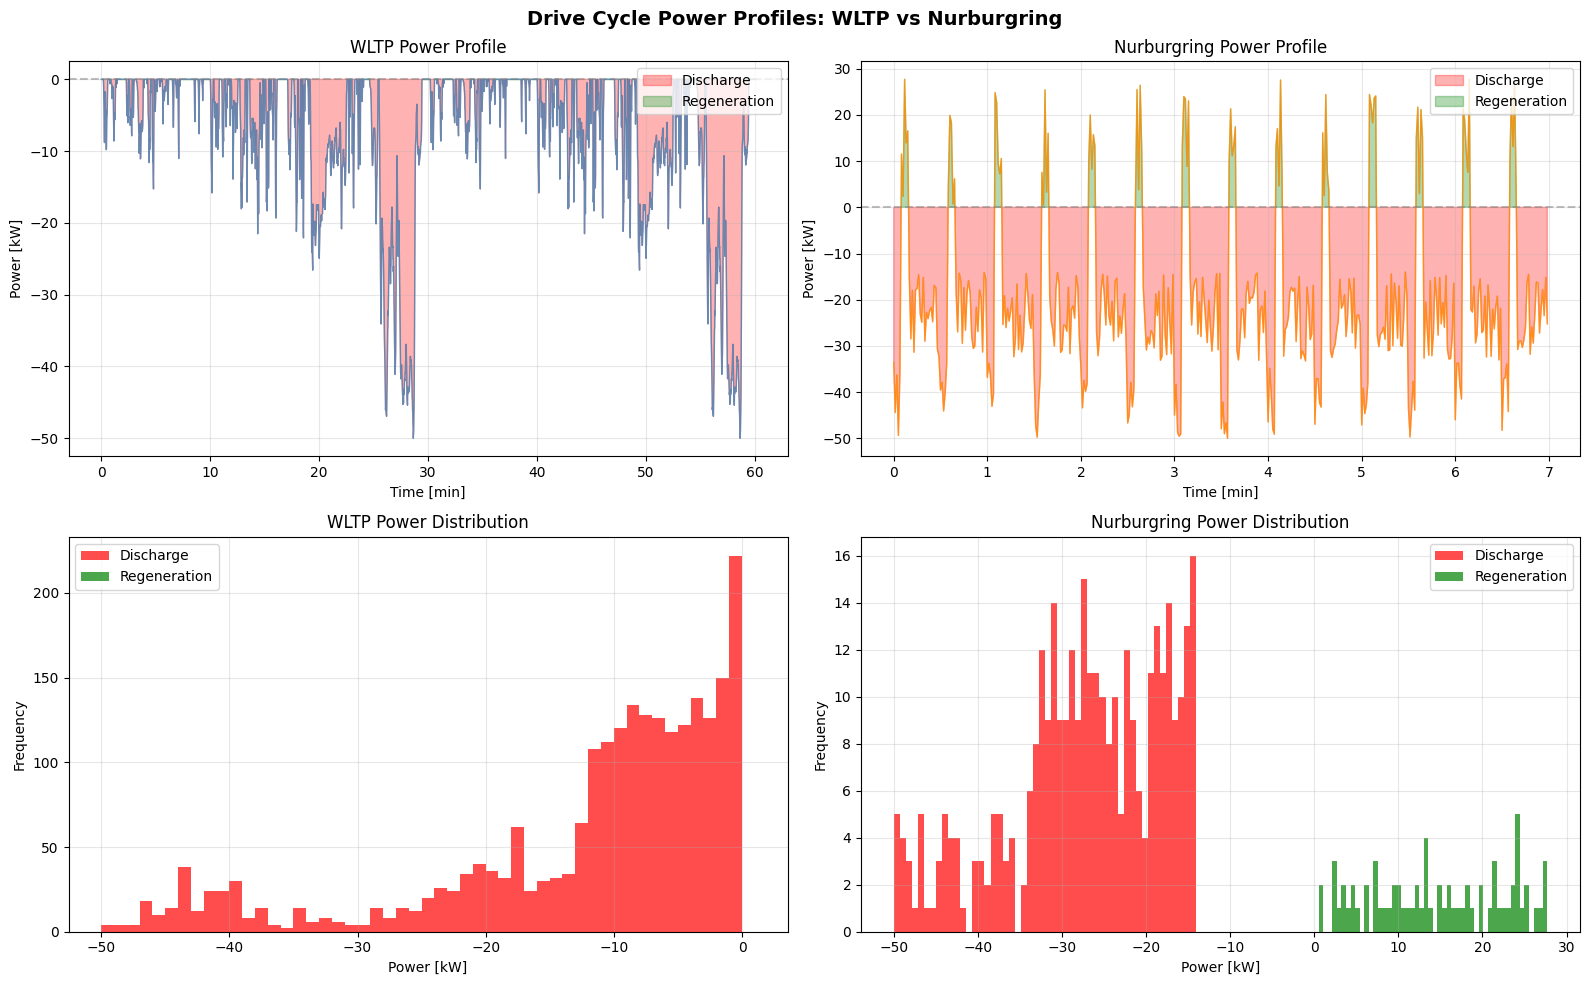

In [5]:
# Visualize both drive cycles
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# WLTP Power profile
ax1 = axes[0, 0]
wltp_time_min = wltp_data['time (s)'] / 60
wltp_power_kW = wltp_data["power (W)"] / wltp_data["power (W)"].abs().max() * pack_config["rated_peak_power_kW"]

# Fill discharge (negative) and regeneration (positive) areas
ax1.fill_between(wltp_time_min, 0, wltp_power_kW, where=(wltp_power_kW < 0), 
                  color='red', alpha=0.3, label='Discharge', interpolate=True)
ax1.fill_between(wltp_time_min, 0, wltp_power_kW, where=(wltp_power_kW >= 0), 
                  color='green', alpha=0.3, label='Regeneration', interpolate=True)
ax1.plot(wltp_time_min, wltp_power_kW, linewidth=1, color='steelblue', alpha=0.8)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Time [min]')
ax1.set_ylabel('Power [kW]')
ax1.set_title('WLTP Power Profile')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# WLTP Power histogram
ax2 = axes[1, 0]
wltp_power_scaled = wltp_data["power (W)"] / wltp_data["power (W)"].abs().max() * pack_config["rated_peak_power_kW"]
wltp_discharge = wltp_power_scaled[wltp_power_scaled < 0]
wltp_regen = wltp_power_scaled[wltp_power_scaled > 0]
ax2.hist(wltp_discharge, bins=50, alpha=0.7, label='Discharge', color='red')
ax2.hist(wltp_regen, bins=50, alpha=0.7, label='Regeneration', color='green')
ax2.set_xlabel('Power [kW]')
ax2.set_ylabel('Frequency')
ax2.set_title('WLTP Power Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Nurburgring Power profile
ax3 = axes[0, 1]
nurb_time_min = nurburgring_data['time (s)'] / 60
nurb_power_kW = nurburgring_data['power (W)'] / nurburgring_data['power (W)'].abs().max() * pack_config["rated_peak_power_kW"]

# Fill discharge (negative) and regeneration (positive) areas
ax3.fill_between(nurb_time_min, 0, nurb_power_kW, where=(nurb_power_kW < 0), 
                  color='red', alpha=0.3, label='Discharge', interpolate=True)
ax3.fill_between(nurb_time_min, 0, nurb_power_kW, where=(nurb_power_kW >= 0), 
                  color='green', alpha=0.3, label='Regeneration', interpolate=True)
ax3.plot(nurb_time_min, nurb_power_kW, linewidth=1, color='darkorange', alpha=0.8)
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax3.set_xlabel('Time [min]')
ax3.set_ylabel('Power [kW]')
ax3.set_title('Nurburgring Power Profile')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

# Nurburgring Power histogram
ax4 = axes[1, 1]
nurb_power_scaled = nurburgring_data['power (W)'] / nurburgring_data['power (W)'].abs().max() * pack_config["rated_peak_power_kW"]
nurburgring_discharge = nurb_power_scaled[nurb_power_scaled < 0]
nurburgring_regen = nurb_power_scaled[nurb_power_scaled > 0]
ax4.hist(nurburgring_discharge, bins=50, alpha=0.7, label='Discharge', color='red')
ax4.hist(nurburgring_regen, bins=50, alpha=0.7, label='Regeneration', color='green')
ax4.set_xlabel('Power [kW]')
ax4.set_ylabel('Frequency')
ax4.set_title('Nurburgring Power Distribution')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('Drive Cycle Power Profiles: WLTP vs Nurburgring', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [6]:
# WLTP drive cycle simulation
pack_nominal_voltage = pack_config["pack_nominal_voltage_V"]
pack_peak_power_kW = pack_config["rated_peak_power_kW"]
pack_max_energy_kWh = pack_config["pack_max_energy_kWh"]

print(f"Pack Specifications:")
print(f"  Nominal voltage: {pack_nominal_voltage:.1f} V")
print(f"  Peak power: {pack_peak_power_kW:.1f} kW\n")

# Read power from CSV, normalize by abs max, multiply by pack rated peak power
wltp_power_raw = wltp_data['power (W)'].values  # Already in W
wltp_power_abs_max = np.abs(wltp_power_raw).max()
wltp_power_normalized = wltp_power_raw / wltp_power_abs_max
wltp_pack_power_kW = wltp_power_normalized * pack_peak_power_kW

print(f"WLTP Power Processing:")
print(f"  Raw power range: {wltp_power_raw.min():.1f} to {wltp_power_raw.max():.1f} W")
print(f"  Abs max: {wltp_power_abs_max:.1f} W")
print(f"  Pack power range: {wltp_pack_power_kW.min():.1f} to {wltp_pack_power_kW.max():.1f} kW")

wltp_cycle = {
    "time_s": wltp_data['time (s)'].values,
    "power_W": -wltp_pack_power_kW*1000,  # Pack-level power in kW
    "label": "Auto WLTP",
    "distance_km": 23.266  # WLTP Class 3 distance
}

wltp_config = {
    "ambient_temperature": 298.15,
    "initial_temperature": 298.15,
    "contact_resistance": 1e-5,
    "total_heat_transfer_coefficient": 5.0,
    "cooling_surface_area": 3.0,
    "initial_soc": 0.95,
    "upper_voltage_cutoff": upper_voltage_cutoff,
    "lower_voltage_cutoff": lower_voltage_cutoff,
    "period": "1 second",
    "drive_cycle": wltp_cycle,
    "pack_max_energy_kWh": pack_max_energy_kWh,
    "pack_nominal_voltage": pack_nominal_voltage,
    "pack_rated_peak_power": pack_peak_power_kW,
    "min_soc": 0.10,
    "max_soc": 0.95,
}

print("\nRunning WLTP simulation...")
wltp_result = run_drive_cycle(cell_design=cell_design, simulation_config=wltp_config)

Pack Specifications:
  Nominal voltage: 400.0 V
  Peak power: 50.0 kW

WLTP Power Processing:
  Raw power range: -80.9 to 0.0 W
  Abs max: 80.9 W
  Pack power range: -50.0 to 0.0 kW

Running WLTP simulation...
{'ambient_temperature': 298.15, 'initial_temperature': 298.15, 'contact_resistance': 1e-05, 'total_heat_transfer_coefficient': 5.0, 'cooling_surface_area': 3.0, 'initial_soc': 0.95, 'upper_voltage_cutoff': 3.65, 'lower_voltage_cutoff': 2.5, 'period': '1 second', 'drive_cycle': {'time_s': array([   0,    1,    2, ..., 3598, 3599, 3600], shape=(3601,)), 'power_W': array([-0., -0., -0., ..., -0., -0., -0.], shape=(3601,)), 'label': 'Auto WLTP', 'distance_km': 23.266}, 'pack_max_energy_kWh': 120, 'pack_nominal_voltage': 400, 'pack_rated_peak_power': 50, 'min_soc': 0.1, 'max_soc': 0.95}

  Pack config: 125.0S2.2106449925206513P (276.3306240650814 cells)
  Pack power range: -0.0 to 50000.0 W
  Cell power range: -0.0 to 180.9 W

Building model parameters from manifest...

CAPACITY CALIB

In [ ]:
# Nurburgring drive cycle simulation
# Read power from CSV, normalize, and scale to pack power
nurburgring_power_raw = nurburgring_data['power (W)'].values  # Already in W
nurburgring_power_abs_max = np.abs(nurburgring_power_raw).max()
nurburgring_power_normalized = nurburgring_power_raw / nurburgring_power_abs_max
nurburgring_pack_power_kW = nurburgring_power_normalized * pack_peak_power_kW

print(f"Nurburgring Power Processing:")
print(f"  Raw power range: {nurburgring_power_raw.min():.1f} to {nurburgring_power_raw.max():.1f} W")
print(f"  Abs max: {nurburgring_power_abs_max:.1f} W")
print(f"  Pack power range: {nurburgring_pack_power_kW.min():.1f} to {nurburgring_pack_power_kW.max():.1f} kW")

nurburgring_cycle = {
    "time_s": nurburgring_data['time (s)'].values,
    "power_W": nurburgring_pack_power_kW * 1000,  # Pack-level power in W
    "label": "Track Nurburgring",
    "distance_km": 20.8  # Nurburgring Nordschleife length
}

nurburgring_config = {
    "ambient_temperature": 298.15,
    "initial_temperature": 298.15,
    "contact_resistance": 1e-5,
    "total_heat_transfer_coefficient": 10.0,
    "cooling_surface_area": 5.0,
    "initial_soc": 0.95,
    "upper_voltage_cutoff": upper_voltage_cutoff,
    "lower_voltage_cutoff": lower_voltage_cutoff,
    "period": "1 second",
    "drive_cycle": nurburgring_cycle,
    "pack_max_energy_kWh": pack_max_energy_kWh,
    "pack_nominal_voltage": pack_nominal_voltage,
    "pack_rated_peak_power": pack_peak_power_kW,
    "min_soc": 0.10,
    "max_soc": 0.95,
}

print("\nRunning Nurburgring simulation...")
nurburgring_result = run_drive_cycle(cell_design=cell_design, simulation_config=nurburgring_config)

Nurburgring Power Processing:
  Raw power range: -161.9 to 89.7 W
  Abs max: 161.9 W
  Pack power range: -50.0 to 27.7 kW

Running Nurburgring simulation...
{'ambient_temperature': 298.15, 'initial_temperature': 298.15, 'contact_resistance': 1e-05, 'total_heat_transfer_coefficient': 10.0, 'cooling_surface_area': 5.0, 'initial_soc': 0.95, 'upper_voltage_cutoff': 3.65, 'lower_voltage_cutoff': 2.5, 'period': '1 second', 'drive_cycle': {'time_s': array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  9

2026-01-28 00:58:10.849 - [WARNING] simulation.solve(942): Step 'Step([[ 0.00000000e+00 -3.35746948e+04]
 [ 1.00000000e+00 -4.44228804e+04]
 [ 2.00000000e+00 -3.63256143e+04]
 [ 3.00000000e+00 -4.93851800e+04]
 [ 4.00000000e+00 -3.58357230e+04]
 [ 5.00000000e+00  1.15252734e+04]
 [ 6.00000000e+00  2.37245786e+03]
 [ 7.00000000e+00  2.77100334e+04]
 [ 8.00000000e+00  1.39594743e+04]
 [ 9.00000000e+00  1.65498694e+04]
 [ 1.00000000e+01 -1.52036234e+04]
 [ 1.10000000e+01 -2.84910734e+04]
 [ 1.20000000e+01 -1.79827700e+04]
 [ 1.30000000e+01 -3.13726598e+04]
 [ 1.40000000e+01 -1.78900348e+04]
 [ 1.50000000e+01 -1.76088316e+04]
 [ 1.60000000e+01 -1.46096375e+04]
 [ 1.70000000e+01 -2.30838646e+04]
 [ 1.80000000e+01 -2.48890503e+04]
 [ 1.90000000e+01 -1.51770082e+04]
 [ 2.00000000e+01 -2.89885549e+04]
 [ 2.10000000e+01 -2.27184831e+04]
 [ 2.20000000e+01 -2.41019637e+04]
 [ 2.30000000e+01 -2.24747524e+04]
 [ 2.40000000e+01 -2.16964448e+04]
 [ 2.50000000e+01 -2.47878539e+04]
 [ 2.60000000e+01 -1

  Unexpected error: 'EmptySolution' object is not subscriptable


In [8]:
print("\n" + "="*80)
print("WLTP SIMULATION RESULTS")
print("="*80)
print_drive_cycle_report(wltp_result)

print("\n\n" + "="*80)
print("NURBURGRING SIMULATION RESULTS")
print("="*80)
print_drive_cycle_report(nurburgring_result)


WLTP SIMULATION RESULTS
DRIVE CYCLE SIMULATION REPORT

──────────────────────────────────────────────────────────────────────
SIMULATION SUMMARY
──────────────────────────────────────────────────────────────────────
  Duration:        3600.0 s (60.0 min)
  Data points:     3601
  Voltage:         3.606 - 3.636 V
  Current:         -0.0 - 50.2 A
  Power:           -0.0 - 180.9 W
  Temperature:     25.0 - 25.0 °C
  Temp rise:       0.0 °C

──────────────────────────────────────────────────────────────────────
ENERGY ANALYSIS
──────────────────────────────────────────────────────────────────────
  Energy discharged:   28.69 Wh
  Energy regenerated:  0.00 Wh
  Net energy:          28.69 Wh
  Capacity used:       7.93 Ah
  SOC change:          5.8%
  Regen ratio:         0.0%

──────────────────────────────────────────────────────────────────────
RANGE ANALYSIS
──────────────────────────────────────────────────────────────────────
  Drive cycle:         Auto WLTP
  Cycle duration:      360

Fast Charge Configuration:
  Initial SOC: 10%
  Charge C-rate: 10.0C (1611.0 A)
  Anode potential threshold: 0.02 V
  Max charge time: 60 minutes
  Max temperature: 45 C
  Upper voltage cutoff: 4.2 V


In [9]:
if wltp_result['success'] and nurburgring_result['success']:
    wltp_ts = wltp_result['timeseries']
    nurb_ts = nurburgring_result['timeseries']
    
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    
    wltp_time_min = np.array(wltp_ts['time_s']) / 60
    nurb_time_min = np.array(nurb_ts['time_s']) / 60
    
    # Voltage comparison
    ax1 = axes[0, 0]
    ax1.plot(wltp_time_min, wltp_ts['voltage_V'], linewidth=2, color='steelblue', label='WLTP')
    ax1.set_xlabel('Time [min]')
    ax1.set_ylabel('Voltage [V]')
    ax1.set_title('WLTP: Cell Voltage')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2 = axes[0, 1]
    ax2.plot(nurb_time_min, nurb_ts['voltage_V'], linewidth=2, color='darkorange', label='Nurburgring')
    ax2.set_xlabel('Time [min]')
    ax2.set_ylabel('Voltage [V]')
    ax2.set_title('Nurburgring: Cell Voltage')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Current comparison
    ax3 = axes[1, 0]
    ax3.plot(wltp_time_min, wltp_ts['current_A'], linewidth=2, color='steelblue', label='WLTP')
    ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax3.set_xlabel('Time [min]')
    ax3.set_ylabel('Current [A]')
    ax3.set_title('WLTP: Cell Current')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    ax4 = axes[1, 1]
    ax4.plot(nurb_time_min, nurb_ts['current_A'], linewidth=2, color='darkorange', label='Nurburgring')
    ax4.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax4.set_xlabel('Time [min]')
    ax4.set_ylabel('Current [A]')
    ax4.set_title('Nurburgring: Cell Current')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # Temperature comparison
    ax5 = axes[2, 0]
    wltp_temp_C = np.array(wltp_ts['temperature_K']) - 273.15
    ax5.plot(wltp_time_min, wltp_temp_C, linewidth=2, color='red', label='WLTP')
    ax5.set_xlabel('Time [min]')
    ax5.set_ylabel('Temperature [°C]')
    ax5.set_title('WLTP: Cell Temperature')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    ax6 = axes[2, 1]
    nurb_temp_C = np.array(nurb_ts['temperature_K']) - 273.15
    ax6.plot(nurb_time_min, nurb_temp_C, linewidth=2, color='red', label='Nurburgring')
    ax6.set_xlabel('Time [min]')
    ax6.set_ylabel('Temperature [°C]')
    ax6.set_title('Nurburgring: Cell Temperature')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    plt.suptitle('WLTP vs Nurburgring Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [10]:
if wltp_result['success'] and nurburgring_result['success']:
    # Extract data
    wltp_summary = wltp_result['summary']
    nurb_summary = nurburgring_result['summary']
    wltp_energy = wltp_result['energy_analysis']
    nurb_energy = nurburgring_result['energy_analysis']
    wltp_range = wltp_result['range_analysis']
    nurb_range = nurburgring_result['range_analysis']
    
    # Create comparison DataFrame
    comparison = pd.DataFrame({
        'Metric': [
            'Duration [min]',
            'Distance [km]',
            'Net Energy [Wh]',
            'Energy per km [Wh/km]',
            'Peak Current [A]',
            'Peak C-rate',
            'Temperature Rise [°C]',
            'Regeneration [%]',
            'Cycles Possible',
            'Total Range [km]'
        ],
        'WLTP': [
            f"{wltp_summary['duration_min']:.1f}",
            f"{wltp_range['cycle_distance_km']:.1f}",
            f"{wltp_energy['energy_net_Wh']:.1f}",
            f"{wltp_range['energy_per_km_Wh']:.1f}",
            f"{wltp_summary['current_max_A']:.1f}",
            f"{wltp_summary['current_max_A']/nominal_capacity:.2f}",
            f"{wltp_summary['temperature_rise_C']:.2f}",
            f"{wltp_energy['regeneration_ratio_pct']:.1f}",
            f"{wltp_range['cycles_possible']:.1f}",
            f"{wltp_range.get('range_km', 0):.1f}"
        ],
        'Nurburgring': [
            f"{nurb_summary['duration_min']:.1f}",
            f"{nurb_range['cycle_distance_km']:.1f}",
            f"{nurb_energy['energy_net_Wh']:.1f}",
            f"{nurb_range['energy_per_km_Wh']:.1f}",
            f"{nurb_summary['current_max_A']:.1f}",
            f"{nurb_summary['current_max_A']/nominal_capacity:.2f}",
            f"{nurb_summary['temperature_rise_C']:.2f}",
            f"{nurb_energy['regeneration_ratio_pct']:.1f}",
            f"{nurb_range['cycles_possible']:.1f}",
            f"{nurb_range.get('range_km', 0):.1f}"
        ]
    })
    
    print("\n" + "="*80)
    print("WLTP vs NURBURGRING COMPARISON")
    print("="*80)
    print(comparison.to_string(index=False))
    
    # Key insights
    print("\n" + "="*80)
    print("KEY INSIGHTS")
    print("="*80)
    
    energy_increase_pct = (nurb_range['energy_per_km_Wh'] / wltp_range['energy_per_km_Wh'] - 1) * 100
    print(f"\n1. Energy Consumption:")
    print(f"   Nurburgring uses {energy_increase_pct:.1f}% more energy per km than WLTP")
    
    range_ratio = wltp_range.get('range_km', 0) / nurb_range.get('range_km', 0) if nurb_range.get('range_km', 0) > 0 else 0
    print(f"\n2. Range Impact:")
    print(f"   WLTP range is {range_ratio:.1f}x the Nurburgring range")
    
    print(f"\n3. Thermal Load:")
    print(f"   Nurburgring: {nurb_summary['temperature_rise_C']:.2f}°C rise")
    print(f"   WLTP: {wltp_summary['temperature_rise_C']:.2f}°C rise")
    print(f"   Difference: {nurb_summary['temperature_rise_C'] - wltp_summary['temperature_rise_C']:.2f}°C")
    
    print(f"\n4. Power Demand:")
    print(f"   Nurburgring peak: {nurb_summary['current_max_A']:.1f}A ({nurb_summary['current_max_A']/nominal_capacity:.1f}C)")
    print(f"   WLTP peak: {wltp_summary['current_max_A']:.1f}A ({wltp_summary['current_max_A']/nominal_capacity:.1f}C)")
    
    # Pack-level comparison
    wltp_pack_energy_kWh = wltp_energy['energy_net_Wh'] * total_cells / 1000
    nurb_pack_energy_kWh = nurb_energy['energy_net_Wh'] * total_cells / 1000
    
    print(f"\n5. Pack-Level Performance ({total_cells}-cell pack, {pack_energy_kWh:.1f} kWh):")
    print(f"   WLTP cycle energy: {wltp_pack_energy_kWh:.2f} kWh ({wltp_pack_energy_kWh/pack_energy_kWh*100:.1f}% of pack)")
    print(f"   Nurburgring lap energy: {nurb_pack_energy_kWh:.2f} kWh ({nurb_pack_energy_kWh/pack_energy_kWh*100:.1f}% of pack)")

In [11]:
if wltp_result['success'] and nurburgring_result['success']:
    # Export WLTP timeseries
    wltp_ts_df = pd.DataFrame(wltp_result['timeseries'])
    wltp_ts_df.to_csv('wltp_timeseries.csv', index=False)
    print("WLTP timeseries exported to: wltp_timeseries.csv")
    
    # Export Nurburgring timeseries
    nurb_ts_df = pd.DataFrame(nurburgring_result['timeseries'])
    nurb_ts_df.to_csv('nurburgring_timeseries.csv', index=False)
    print("Nurburgring timeseries exported to: nurburgring_timeseries.csv")
    
    # Export comparison summary
    summary_data = [
        {
            'cycle': 'WLTP',
            **wltp_result['summary'],
            **wltp_result['energy_analysis'],
            **wltp_result['range_analysis']
        },
        {
            'cycle': 'Nurburgring',
            **nurburgring_result['summary'],
            **nurburgring_result['energy_analysis'],
            **nurburgring_result['range_analysis']
        }
    ]
    summary_df = pd.DataFrame(summary_data)
    summary_df.to_csv('drive_cycle_comparison.csv', index=False)
    print("Comparison summary exported to: drive_cycle_comparison.csv")

## 10. Export Results

Export timeseries and comparison data to CSV files.

## 9. Comparison Table

Create a detailed comparison table of key metrics.

## 8. Side-by-Side Visualization

Compare voltage, current, and temperature profiles.

## 7. Display Simulation Results

Print detailed reports for both simulations.

## 6. Run Nurburgring Simulation

Simulate the Nurburgring track cycle.

## 5. Run WLTP Simulation

Simulate the WLTP standard driving cycle.

## 4. Visualize Drive Cycles

Compare the power profiles of both drive cycles.

## 3. Load Drive Cycle Data

Load both WLTP and Nurburgring power profiles from CSV files.

## 2. Configure Battery Pack

Define a 120S3P battery pack configuration (~100 kWh, 400V) for both simulations.

In [12]:
# Import required libraries
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from model_library.spmet_drive import run_drive_cycle, print_drive_cycle_report